<a href="https://colab.research.google.com/github/vadhri/ai-notebook/blob/main/timeseries/seasonality_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A diet plan has the following details.
- Rice every 2 days
- Roti every 3 days
- Noodles every 4 days

Given a timeseries find if the consumption pattern fits the expected time proposed ane measure deviation.


In [244]:
import numpy as np
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [245]:
Days = 365
def generate_food_series(days=60, coefficient_deviation=0):
    expected = {'Rice': 2, 'Roti': 3, 'Noodles': 4}
    events = []

    for food, interval in expected.items():
        day = 0
        while day <= days:
            deviation = coefficient_deviation * np.random.choice([-1, 0, 1], p=[0.2, 0.6, 0.2])
            events.append((day, food))
            day += interval + deviation

    df = pd.DataFrame(events, columns=["Day", "Food"])
    return df.sort_values("Day").reset_index(drop=True)

df = generate_food_series(Days, 0)
df

,Day,Food
0,0,Rice
1,0,Noodles
2,0,Roti
3,2,Rice
4,3,Roti
...,...,...
392,360,Noodles
393,362,Rice
394,363,Roti
395,364,Rice


In [246]:
# Daily timestamp index
ts = pd.DataFrame({"ds": pd.date_range("2024-01-01", periods=Days, freq="D")})

# Generate a day_number column that matches your df.Day
ts["day_number"] = np.arange(1, Days + 1)

# Convert to 0/1 signals for each food
for food in ["Rice", "Roti", "Noodles"]:
    ts[food] = ts["day_number"].apply(
        lambda d: int((df[(df.Day == d) & (df.Food == food)]).shape[0] > 0)
    )

# Drop helper column
ts = ts.drop(columns=["day_number"])


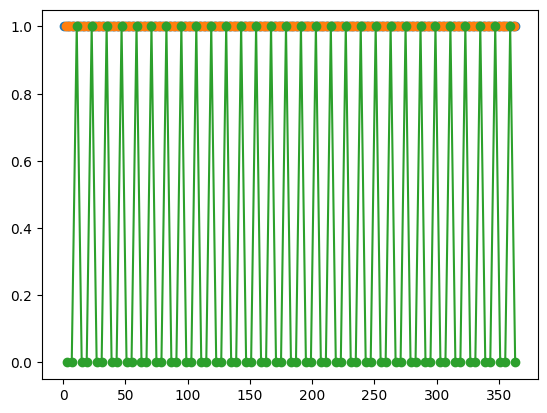

In [247]:
xs = np.arange(Days)

rice = ts.Rice
roti = ts.Roti
noodles = ts.Noodles

rice_mask = ts['Rice'] > 0
roti_mask = ts['Roti'] > 0
noodles_mask = ts['Noodles'] > 0

plt.plot(xs[rice_mask], rice[rice_mask], linestyle='-', marker='o')
plt.plot(xs[roti_mask], roti[roti_mask], linestyle='-', marker='o')
plt.plot(xs[noodles_mask], roti[noodles_mask], linestyle='-', marker='o')

plt.show()


In [248]:
def fit_prophet(food, data):
    m = Prophet(weekly_seasonality=False, daily_seasonality=False)

    # Add custom seasonalities
    period_map = {"Rice": 2, "Roti": 3, "Noodles": 4}

    m.add_seasonality(
        name=f"{food}_seasonality",
        period=period_map[food],
        fourier_order=3
    )

    dfp = data[["ds", food]].rename(columns={food: "y"})
    m.fit(dfp)
    future = m.make_future_dataframe(periods=0)
    forecast = m.predict(future)

    return m, forecast

models = {}
forecasts = {}

for food in ["Rice", "Roti", "Noodles"]:
    models[food], forecasts[food] = fit_prophet(food, ts)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.



==== Rice Seasonality Components ====


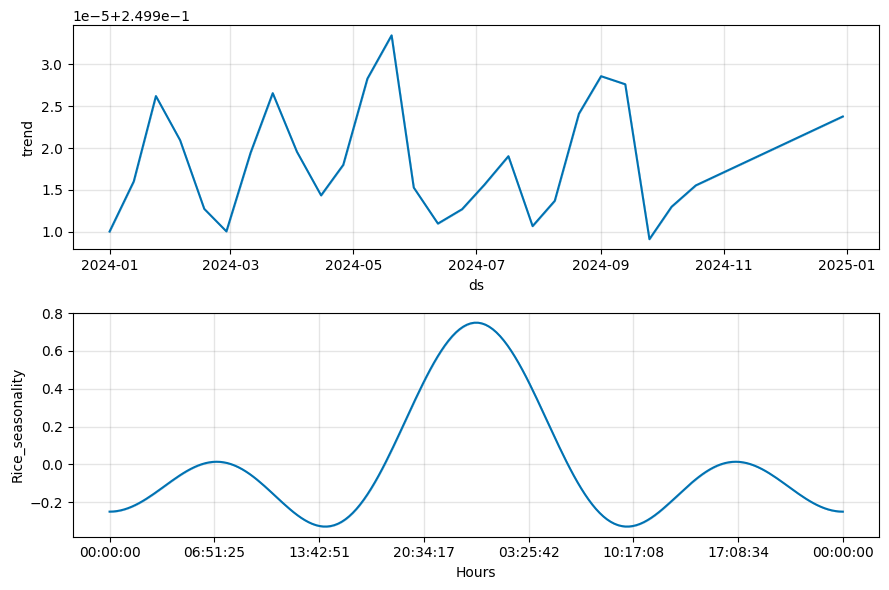


==== Roti Seasonality Components ====


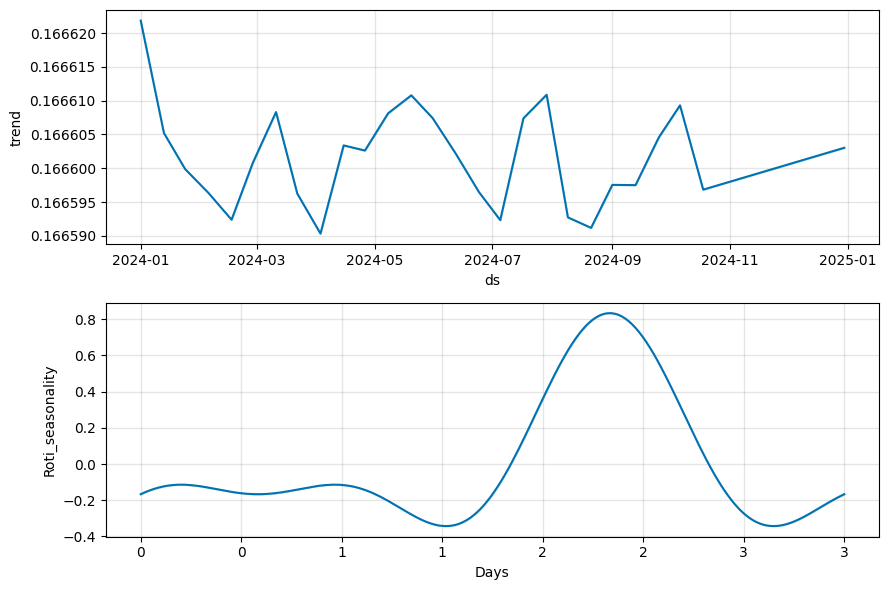


==== Noodles Seasonality Components ====


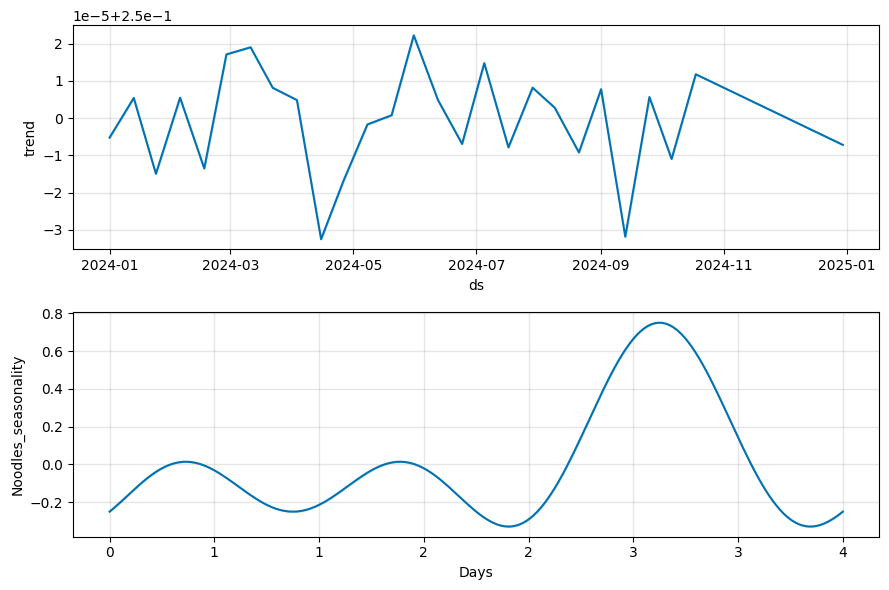

In [249]:
for food in ["Rice", "Roti", "Noodles"]:
    print(f"\n==== {food} Seasonality Components ====")
    fig = models[food].plot_components(forecasts[food])
    plt.show()

In [250]:
for food in ["Rice", "Roti", "Noodles"]:
    custom_seasonality_name = f"{food}_seasonality"
    if custom_seasonality_name in models[food].seasonalities:
        period = models[food].seasonalities[custom_seasonality_name]['period']
        print(f"{food} Seasonality Period: {period} days")
    else:
        print(f"Custom seasonality '{custom_seasonality_name}' not found for {food}.")

Rice Seasonality Period: 2 days
Roti Seasonality Period: 3 days
Noodles Seasonality Period: 4 days


In [251]:
import numpy as np
import pandas as pd

def prophet_seasonality_deviation(food, model, forecast, data):
    dfp = data[["ds", food]].rename(columns={food: "y"})

    # Prophet writes custom seasonality columns like this
    seasonal_col = f"{food}_seasonality"
    if seasonal_col not in forecast.columns:
        # New Prophet versions use this name for custom seasonality
        seasonal_col = f"extra_regressors_additive_{food}_seasonality"

    seasonal_component = forecast[seasonal_col].values
    yhat = forecast["yhat"].values
    y = dfp["y"].values

    # Prophet residual (total)
    residual = y - yhat

    # Component-level deviation (pure seasonality mismatch)
    seasonal_residual = y - seasonal_component

    # RMSE deviation from seasonality
    rmse = np.sqrt(np.mean(seasonal_residual**2))

    # Prophet-style seasonality strength
    strength = np.var(seasonal_component) / (np.var(seasonal_component) + np.var(residual) + 1e-8)

    return {
        "seasonality_rmse": rmse,
        "seasonality_strength": strength,
        "seasonal_component_variance": np.var(seasonal_component),
        "residual_variance": np.var(residual)
    }

deviations = {}

period_map = {"Rice": 2, "Roti": 3, "Noodles": 5}

for food in ["Rice", "Roti", "Noodles"]:
    deviations[food] = prophet_seasonality_deviation(
        food, models[food], forecasts[food], ts
    )

deviations

{'Rice': {'seasonality_rmse': np.float64(0.24991859928780646),
  'seasonality_strength': np.float64(0.9999999598793025),
  'seasonal_component_variance': np.float64(0.2499978634773429),
  'residual_variance': np.float64(3.0089078841948495e-11)},
 'Roti': {'seasonality_rmse': np.float64(0.1666013136438572),
  'seasonality_strength': np.float64(0.9999999547330911),
  'seasonal_component_variance': np.float64(0.221610133519692),
  'residual_variance': np.float64(3.1606196327667614e-11)},
 'Noodles': {'seasonality_rmse': np.float64(0.24999999964734235),
  'seasonality_strength': np.float64(0.9999999460013627),
  'seasonal_component_variance': np.float64(0.18715729929572522),
  'residual_variance': np.float64(1.0623969680885185e-10)}}

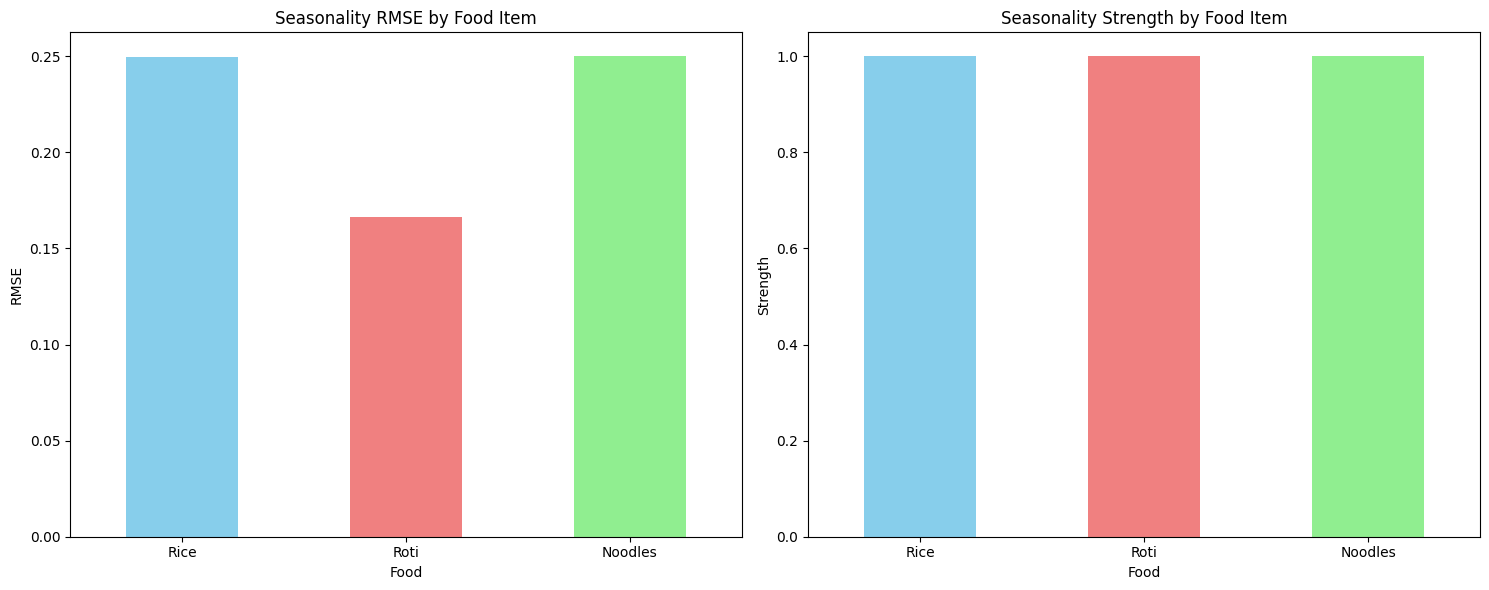

In [252]:
import matplotlib.pyplot as plt
import pandas as pd

deviation_data = []
for food, metrics in deviations.items():
    deviation_data.append({
        'Food': food,
        'Seasonality RMSE': metrics['seasonality_rmse'],
        'Seasonality Strength': metrics['seasonality_strength']
    })

deviation_df = pd.DataFrame(deviation_data)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

deviation_df.plot(x='Food', y='Seasonality RMSE', kind='bar', ax=axes[0], legend=False, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[0].set_title('Seasonality RMSE by Food Item')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=0)

deviation_df.plot(x='Food', y='Seasonality Strength', kind='bar', ax=axes[1], legend=False, color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1].set_title('Seasonality Strength by Food Item')
axes[1].set_ylabel('Strength')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()